## Gromov Monge

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import matplotlib.pyplot as plt
import torch
import pandas as pd

from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from scipy.spatial.distance import cdist, pdist, squareform
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


from colors import color_segment
from supervised_vae import SupervisedVAE
from train_two_vaes import train_two_vaes
from plot_vaes import plot_vae_latent_alignment
from utils_GW import *
from geodesics import *

blue_pink = color_segment()

In [3]:
# --- config ---
latent_dim = 8
num_classes = 3
prefix = "checkpoints/mnist_same_3classes"  # must match training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- load models ---
vaeA = SupervisedVAE(latent_dim=latent_dim, num_classes=num_classes)
vaeB = SupervisedVAE(latent_dim=latent_dim, num_classes=num_classes)

vaeA.load_state_dict(torch.load(f"{prefix}_vaeA.pt", map_location=device))
vaeB.load_state_dict(torch.load(f"{prefix}_vaeB.pt", map_location=device))

vaeA.to(device).eval()
vaeB.to(device).eval()

# --- load data splits (need align + test) ---
A_align = torch.load(f"{prefix}_A_align.pt", map_location="cpu")
B_align = torch.load(f"{prefix}_B_align.pt", map_location="cpu")

A_test = torch.load(f"{prefix}_A_test.pt", map_location="cpu")
B_test = torch.load(f"{prefix}_B_test.pt", map_location="cpu")

# --- extract latents (with labels) ---
zA_align = A_align["z"]
zB_align = B_align["z"]
y_align  = A_align["y"]

zA_test = A_test["z"]
zB_test = B_test["z"]
y_test  = A_test["y"]

In [4]:
# ============================================================
# 0) Basic tensor / permutation utilities
# ============================================================

def as_tensor(x, device=device, dtype=torch.float32):
    if torch.is_tensor(x):
        return x.to(device=device, dtype=dtype)
    return torch.tensor(x, device=device, dtype=dtype)

def as_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def invert_permutation(perm):
    perm = np.asarray(perm, dtype=int)
    inv = np.empty_like(perm)
    inv[perm] = np.arange(len(perm))
    return inv

def make_random_permutation(n, seed=0):
    rng = np.random.default_rng(seed)
    return rng.permutation(n)

def permute_rows_tensor(X, perm):
    perm_t = torch.as_tensor(perm, device=X.device, dtype=torch.long)
    return X[perm_t]

def select_anchor_subset(zA_anchor, zB_anchor, y_anchor=None, n_keep=40, seed=0):
    """
    Select the same anchor indices from A and B.
    This keeps the hidden correspondence intact.
    """
    n_total = len(zA_anchor)
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_total, size=min(n_keep, n_total), replace=False)
    idx = np.sort(idx)

    zA_sub = zA_anchor[idx]
    zB_sub = zB_anchor[idx]

    if y_anchor is None:
        return zA_sub, zB_sub, None, idx
    return zA_sub, zB_sub, y_anchor[idx], idx

In [5]:
# ============================================================
# 1) Pairwise geodesic distance matrix in A-geometry
# ============================================================

def pairwise_geodesic_matrix_in_A(
    vaeA_model,
    latent_points,
    num_segments=10,
    device=device,
    detach=False,
):
    """
    Compute the NxN pairwise geodesic distance matrix using A's decoder geometry.
    Distances are approximated with linear_path_energy.
    """
    Z = as_tensor(latent_points, device=device)
    n = Z.shape[0]

    D = torch.zeros(n, n, device=device, dtype=Z.dtype)

    was_training = vaeA_model.training
    vaeA_model.eval()

    context = torch.no_grad() if detach else torch.enable_grad()
    with context:
        for i in range(n):
            for j in range(i + 1, n):
                _, d_ij = linear_path_energy(
                    vaeA_model,
                    Z[i],
                    Z[j],
                    num_segments=num_segments,
                    device=device,
                )
                D[i, j] = d_ij
                D[j, i] = d_ij

    if was_training:
        vaeA_model.train()

    return D

In [6]:
# ============================================================
# 2) Flow model constructor
#    Uses ZukoFlowMap already available from utils_GW import *
# ============================================================

def build_flow_model(
    latent_dim,
    transforms=4,
    hidden_features=(64, 64),
    bins=8,
):
    return ZukoFlowMap(
        latent_dim=latent_dim,
        transforms=transforms,
        hidden_features=hidden_features,
        bins=bins,
    ).to(device)

In [7]:
# ============================================================
# 3) Single GM objective for fixed permutation
# ============================================================

def gromov_monge_objective_fixed_perm(
    flow_model,
    zA_anchor,
    zB_anchor,
    perm_B_to_A,
    vaeA_model,
    D_A_anchor=None,
    num_segments=10,
    device=device,
):
    """
    Objective:
        mean( D_A(zA_anchor) - D_A(T(zB_anchor permuted into A-order)) )^2

    All distances are measured in A-geometry.
    """
    ZA = as_tensor(zA_anchor, device=device)
    ZB = as_tensor(zB_anchor, device=device)

    if D_A_anchor is None:
        D_A_anchor = pairwise_geodesic_matrix_in_A(
            vaeA_model,
            ZA,
            num_segments=num_segments,
            device=device,
            detach=True,
        ).detach()

    ZB_in_A_order = permute_rows_tensor(ZB, perm_B_to_A)
    TZB = flow_model(ZB_in_A_order)

    D_A_of_mapped_B = pairwise_geodesic_matrix_in_A(
        vaeA_model,
        TZB,
        num_segments=num_segments,
        device=device,
        detach=False,
    )

    loss = ((D_A_anchor - D_A_of_mapped_B) ** 2).mean()
    return loss, D_A_anchor, TZB

In [8]:
# ============================================================
# 4) Fit flow for fixed permutation
# ============================================================

def fit_flow_with_fixed_permutation(
    zA_anchor,
    zB_anchor,
    perm_B_to_A,
    vaeA_model,
    flow_model=None,
    transforms=4,
    hidden_features=(64, 64),
    bins=8,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=150,
    num_segments=10,
    device=device,
    verbose=True,
):
    """
    Optimize only the flow T, with permutation fixed.
    """
    ZA = as_tensor(zA_anchor, device=device)
    D_A_anchor = pairwise_geodesic_matrix_in_A(
        vaeA_model,
        ZA,
        num_segments=num_segments,
        device=device,
        detach=True,
    ).detach()

    if flow_model is None:
        latent_dim = ZA.shape[1]
        flow_model = build_flow_model(
            latent_dim=latent_dim,
            transforms=transforms,
            hidden_features=hidden_features,
            bins=bins,
        )

    optimizer = torch.optim.Adam(
        flow_model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_loss = float("inf")
    best_state = None

    flow_model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()

        loss, _, _ = gromov_monge_objective_fixed_perm(
            flow_model=flow_model,
            zA_anchor=zA_anchor,
            zB_anchor=zB_anchor,
            perm_B_to_A=perm_B_to_A,
            vaeA_model=vaeA_model,
            D_A_anchor=D_A_anchor,
            num_segments=num_segments,
            device=device,
        )

        loss.backward()
        optimizer.step()

        loss_value = loss.item()

        if loss_value < best_loss:
            best_loss = loss_value
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in flow_model.state_dict().items()
            }

        if verbose and ((epoch + 1) % 25 == 0 or epoch == 0):
            print(
                f"[flow step] epoch={epoch+1:4d} "
                f"loss={loss_value:.6f} best={best_loss:.6f}"
            )

    if best_state is not None:
        flow_model.load_state_dict(best_state)

    return flow_model, best_loss, D_A_anchor

In [9]:
# ============================================================
# 5) Evaluate permutation under the current flow
# ============================================================

@torch.no_grad()
def evaluate_permutation_under_flow(
    flow_model,
    zA_anchor,
    zB_anchor,
    perm_B_to_A,
    vaeA_model,
    D_A_anchor=None,
    num_segments=10,
    device=device,
):
    ZA = as_tensor(zA_anchor, device=device)
    ZB = as_tensor(zB_anchor, device=device)

    if D_A_anchor is None:
        D_A_anchor = pairwise_geodesic_matrix_in_A(
            vaeA_model,
            ZA,
            num_segments=num_segments,
            device=device,
            detach=True,
        ).detach()

    ZB_in_A_order = permute_rows_tensor(ZB, perm_B_to_A)
    TZB = flow_model(ZB_in_A_order)

    D_A_of_mapped_B = pairwise_geodesic_matrix_in_A(
        vaeA_model,
        TZB,
        num_segments=num_segments,
        device=device,
        detach=True,
    )

    return ((D_A_anchor - D_A_of_mapped_B) ** 2).mean().item()

In [10]:
# ============================================================
# 6) Greedy permutation update by pair swaps
# ============================================================

@torch.no_grad()
def update_permutation_by_greedy_swaps(
    flow_model,
    zA_anchor,
    zB_anchor,
    current_perm_B_to_A,
    vaeA_model,
    D_A_anchor=None,
    num_segments=10,
    max_candidate_swaps=200,
    seed=0,
    device=device,
    verbose=True,
):
    """
    Greedy local search on the permutation under the SAME GM objective.
    This is expensive; keep anchor sets small first.
    """
    rng = np.random.default_rng(seed)
    perm = np.asarray(current_perm_B_to_A, dtype=int).copy()
    n = len(perm)

    current_loss = evaluate_permutation_under_flow(
        flow_model=flow_model,
        zA_anchor=zA_anchor,
        zB_anchor=zB_anchor,
        perm_B_to_A=perm,
        vaeA_model=vaeA_model,
        D_A_anchor=D_A_anchor,
        num_segments=num_segments,
        device=device,
    )

    all_swaps = [(i, j) for i in range(n) for j in range(i + 1, n)]
    if len(all_swaps) > max_candidate_swaps:
        chosen = rng.choice(len(all_swaps), size=max_candidate_swaps, replace=False)
        candidate_swaps = [all_swaps[k] for k in chosen]
    else:
        candidate_swaps = all_swaps

    improved = False

    for i, j in candidate_swaps:
        trial_perm = perm.copy()
        trial_perm[i], trial_perm[j] = trial_perm[j], trial_perm[i]

        trial_loss = evaluate_permutation_under_flow(
            flow_model=flow_model,
            zA_anchor=zA_anchor,
            zB_anchor=zB_anchor,
            perm_B_to_A=trial_perm,
            vaeA_model=vaeA_model,
            D_A_anchor=D_A_anchor,
            num_segments=num_segments,
            device=device,
        )

        if trial_loss < current_loss:
            perm = trial_perm
            current_loss = trial_loss
            improved = True

    if verbose:
        print(f"[perm step] loss={current_loss:.6f} improved={improved}")

    return perm, current_loss, improved

In [11]:
# ============================================================
# 7) Alternating GM optimization: permutation + flow
# ============================================================

def alternating_gromov_monge_flow_fit(
    zA_anchor,
    zB_anchor,
    vaeA_model,
    initial_perm_B_to_A=None,
    flow_model=None,
    outer_iterations=4,
    flow_epochs_per_iteration=100,
    num_segments=10,
    lr=1e-3,
    weight_decay=1e-5,
    transforms=4,
    hidden_features=(64, 64),
    bins=8,
    max_candidate_swaps=200,
    perm_seed=0,
    device=device,
    verbose=True,
):
    """
    Alternating optimization of:
        min_{perm, T} mean( D_A(zA_anchor) - D_A(T(zB_anchor permuted into A-order)) )^2
    """
    ZA = as_tensor(zA_anchor, device=device)
    D_A_anchor = pairwise_geodesic_matrix_in_A(
        vaeA_model,
        ZA,
        num_segments=num_segments,
        device=device,
        detach=True,
    ).detach()

    n = ZA.shape[0]
    if initial_perm_B_to_A is None:
        perm_B_to_A = np.arange(n)
    else:
        perm_B_to_A = np.asarray(initial_perm_B_to_A, dtype=int).copy()

    if flow_model is None:
        flow_model = build_flow_model(
            latent_dim=ZA.shape[1],
            transforms=transforms,
            hidden_features=hidden_features,
            bins=bins,
        )

    history = []

    for outer_idx in range(outer_iterations):
        if verbose:
            print(f"\n=== OUTER ITERATION {outer_idx + 1}/{outer_iterations} ===")

        flow_model, best_flow_loss, _ = fit_flow_with_fixed_permutation(
            zA_anchor=zA_anchor,
            zB_anchor=zB_anchor,
            perm_B_to_A=perm_B_to_A,
            vaeA_model=vaeA_model,
            flow_model=flow_model,
            lr=lr,
            weight_decay=weight_decay,
            epochs=flow_epochs_per_iteration,
            num_segments=num_segments,
            device=device,
            verbose=verbose,
        )

        perm_B_to_A, perm_loss, improved = update_permutation_by_greedy_swaps(
            flow_model=flow_model,
            zA_anchor=zA_anchor,
            zB_anchor=zB_anchor,
            current_perm_B_to_A=perm_B_to_A,
            vaeA_model=vaeA_model,
            D_A_anchor=D_A_anchor,
            num_segments=num_segments,
            max_candidate_swaps=max_candidate_swaps,
            seed=perm_seed + outer_idx,
            device=device,
            verbose=verbose,
        )

        history.append({
            "outer_iteration": outer_idx + 1,
            "flow_loss": best_flow_loss,
            "perm_loss": perm_loss,
            "perm_improved": improved,
        })

    history_df = pd.DataFrame(history)
    return flow_model, perm_B_to_A, history_df

In [12]:
# ============================================================
# 8) Apply learned flow
# ============================================================

@torch.no_grad()
def apply_learned_flow(flow_model, latent_points, device=device):
    Z = as_tensor(latent_points, device=device)
    flow_model.eval()
    return flow_model(Z).cpu()

In [13]:
## Usage

# Anchor / align split only
zA_anchor = zA_align.clone()
zB_anchor = zB_align.clone()
y_anchor = y_align.clone()

zA_anchor_sub, zB_anchor_sub, y_anchor_sub, anchor_idx = select_anchor_subset(
    zA_anchor=zA_anchor,
    zB_anchor=zB_anchor,
    y_anchor=y_anchor,
    n_keep=30,
    seed=0,
)

perm_true_A_to_shuffledB = make_random_permutation(len(zB_anchor_sub), seed=123)

# shuffled B set
zB_anchor_shuffled = zB_anchor_sub[perm_true_A_to_shuffledB]

# permutation we optimize is "B shuffled order -> A order"
# correct target permutation therefore is the inverse
perm_true_B_to_A = invert_permutation(perm_true_A_to_shuffledB)

In [19]:
zA_anchor.shape

torch.Size([1861, 8])

In [14]:
# run alternating optimization
flow_model, perm_hat_B_to_A, history_df = alternating_gromov_monge_flow_fit(
    zA_anchor=zA_anchor_sub,
    zB_anchor=zB_anchor_shuffled,
    vaeA_model=vaeA,
    initial_perm_B_to_A=np.arange(len(zA_anchor_sub)),
    outer_iterations=4,
    flow_epochs_per_iteration=75,
    num_segments=8,
    lr=1e-3,
    max_candidate_swaps=120,
    verbose=True,
)


=== OUTER ITERATION 1/4 ===
[flow step] epoch=   1 loss=5.624588 best=5.624588
[flow step] epoch=  25 loss=3.751762 best=3.751762
[flow step] epoch=  50 loss=2.385836 best=2.385836
[flow step] epoch=  75 loss=1.358741 best=1.358741
[perm step] loss=1.212776 improved=True

=== OUTER ITERATION 2/4 ===
[flow step] epoch=   1 loss=1.212776 best=1.212776
[flow step] epoch=  25 loss=0.805761 best=0.805761
[flow step] epoch=  50 loss=0.619192 best=0.619192
[flow step] epoch=  75 loss=0.435875 best=0.435875
[perm step] loss=0.430108 improved=False

=== OUTER ITERATION 3/4 ===
[flow step] epoch=   1 loss=0.430108 best=0.430108
[flow step] epoch=  25 loss=0.338564 best=0.338564
[flow step] epoch=  50 loss=0.255882 best=0.255882
[flow step] epoch=  75 loss=0.183144 best=0.183144
[perm step] loss=0.181486 improved=False

=== OUTER ITERATION 4/4 ===
[flow step] epoch=   1 loss=0.181486 best=0.181486
[flow step] epoch=  25 loss=0.189815 best=0.181486
[flow step] epoch=  50 loss=0.160488 best=0.1604

In [16]:
def plot_alignment_2d(
    zA,
    zB,
    zB_mapped,
    labels,
    title_prefix="",
    figsize=(15, 4),
):
    """
    Visualize A, B, and mapped B in the same PCA space.

    zA, zB, zB_mapped : (N, d)
    labels            : (N,)
    """

    zA_np = zA if isinstance(zA, np.ndarray) else zA.numpy()
    zB_np = zB if isinstance(zB, np.ndarray) else zB.numpy()
    zBm_np = zB_mapped if isinstance(zB_mapped, np.ndarray) else zB_mapped.numpy()
    labels_np = labels if isinstance(labels, np.ndarray) else labels.numpy()

    # --- shared PCA ---
    Z_all = np.vstack([zA_np, zB_np, zBm_np])
    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z_all)

    n = len(zA_np)
    A2  = Z2[:n]
    B2  = Z2[n:2*n]
    Bm2 = Z2[2*n:]

    unique_labels = np.unique(labels_np)
    color_map = {k: plt.cm.tab10(int(k)) for k in unique_labels}

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # --- A ---
    for k in unique_labels:
        idx = labels_np == k
        axes[0].scatter(A2[idx, 0], A2[idx, 1],
                        color=color_map[k], marker="+", s=100)
    axes[0].set_title(f"{title_prefix} A")

    # --- B ---
    for k in unique_labels:
        idx = labels_np == k
        axes[1].scatter(B2[idx, 0], B2[idx, 1],
                        color=color_map[k], marker="o", s=60)
    axes[1].set_title(f"{title_prefix} B")

    # --- mapped ---
    for k in unique_labels:
        idx = labels_np == k
        axes[2].scatter(
            A2[idx, 0], A2[idx, 1],
            color=color_map[k], marker="+", s=100,
            label=f"A {k}"
        )
        axes[2].scatter(
            Bm2[idx, 0], Bm2[idx, 1],
            color=color_map[k], marker="o", s=60,
            label=f"B→A {k}"
        )

    axes[2].set_title(f"{title_prefix} mapped B vs A")

    # clean legend
    handles, labels_leg = axes[2].get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    axes[2].legend(by_label.values(), by_label.keys(), fontsize=8)

    plt.tight_layout()
    plt.show()

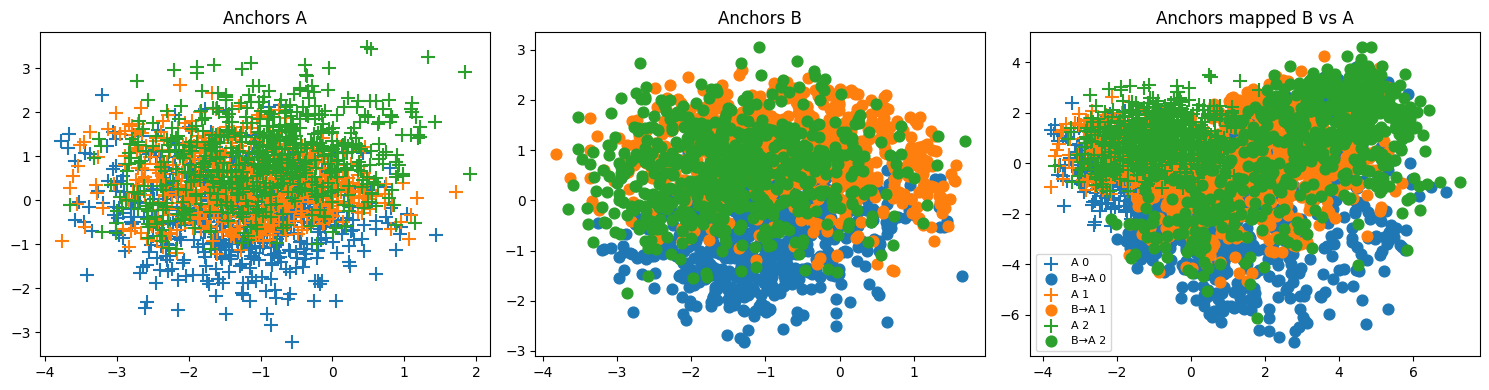

In [17]:
zB_anchor_mapped = apply_learned_flow(
    flow_model,
    zB_anchor.numpy(),
    device=device,
)

plot_alignment_2d(
    zA=zA_anchor,
    zB=zB_anchor,
    zB_mapped=zB_anchor_mapped,
    labels=y_align,   # <-- single label set
    title_prefix="Anchors",
)

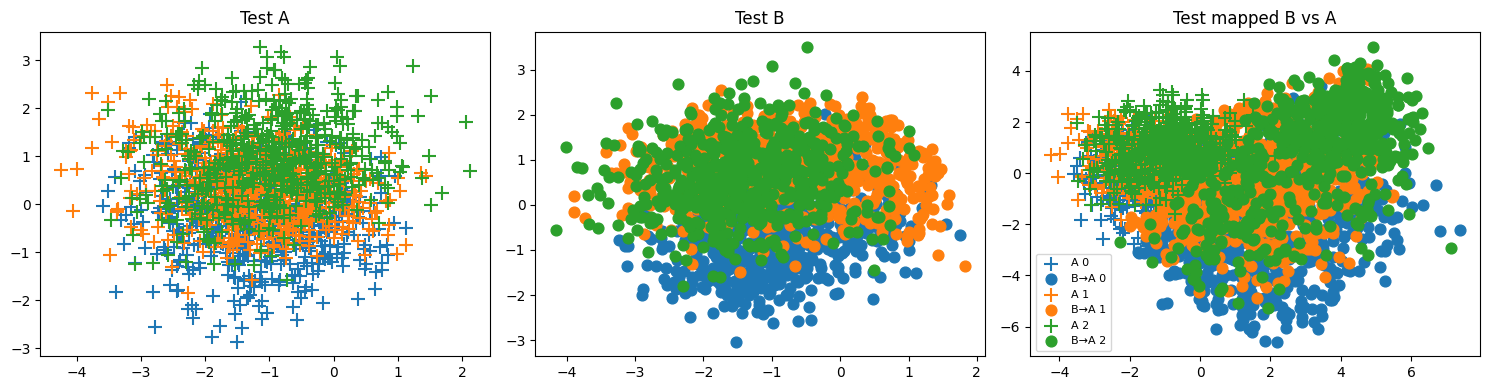

In [20]:
zB_test_mapped = apply_learned_flow(
    flow_model,
    zB_test.numpy(),
    device=device,
)

plot_alignment_2d(
    zA=zA_test,
    zB=zB_test,
    zB_mapped=zB_test_mapped,
    labels=y_test,
    title_prefix="Test",
)